In [1]:
%pip install shap lime

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install shap lime

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import shap
import lime
import lime.lime_tabular

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    brier_score_loss,
    classification_report
)

from sklearn.calibration import (
    calibration_curve,
    CalibrationDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


c:\TANIYA\Stats_Exp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable: Outcome")

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Input Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target Variable: Outcome

Feature Shape: (768, 8)
Target Shape: (768,)


In [8]:
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Potentially invalid zero values:\n")

for column in invalid_columns:
    print(column, ":", (X[column] == 0).sum())

Potentially invalid zero values:

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [9]:
X_clean = X.copy()

for column in invalid_columns:
    X_clean[column] = X_clean[column].replace(0, np.nan)

print("Missing values after replacing invalid zeros:\n")
print(X_clean.isnull().sum())

Missing values after replacing invalid zeros:

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [10]:
for column in invalid_columns:
    X_clean[column] = X_clean[column].fillna(
        X_clean[column].median()
    )

print("Missing values after median imputation:\n")
print(X_clean.isnull().sum())

Missing values after median imputation:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining Outcome Distribution:")
print(y_train.value_counts())

print("\nTesting Outcome Distribution:")
print(y_test.value_counts())

Training samples: 614
Testing samples: 154

Training Outcome Distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing Outcome Distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [12]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [13]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 Predicted Classes:")
print(y_pred[:10])

print("\nFirst 10 Predicted Probabilities:")
print(y_prob[:10])

First 10 Predicted Classes:
[1 0 0 0 0 0 0 1 0 1]

First 10 Predicted Probabilities:
[0.60971073 0.11835576 0.29346313 0.2508367  0.03320667 0.16852385
 0.4881643  0.92367511 0.08143405 0.8385896 ]


In [15]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

test_f1 = f1_score(
    y_test,
    y_pred
)

print("Test Set Performance")
print("--------------------")
print("Accuracy :", round(test_accuracy, 4))
print("F1-Score :", round(test_f1, 4))

Test Set Performance
--------------------
Accuracy : 0.7078
F1-Score : 0.5455


In [16]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Non-Diabetic",
            "Diabetic"
        ]
    )
)

Classification Report:

              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracy = cross_val_score(
    model,
    X_clean,
    y,
    cv=cv,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Accuracy:")
print(cv_accuracy)

print("\nMean CV Accuracy:",
      round(cv_accuracy.mean(), 4))

print("Standard Deviation:",
      round(cv_accuracy.std(), 4))

5-Fold Cross-Validation Accuracy:
[0.77272727 0.7987013  0.77922078 0.75163399 0.76470588]

Mean CV Accuracy: 0.7734
Standard Deviation: 0.0156


In [18]:
cv_f1 = cross_val_score(
    model,
    X_clean,
    y,
    cv=cv,
    scoring="f1"
)

print("5-Fold Cross-Validation F1-Scores:")
print(cv_f1)

print("\nMean CV F1-Score:",
      round(cv_f1.mean(), 4))

print("Standard Deviation:",
      round(cv_f1.std(), 4))

5-Fold Cross-Validation F1-Scores:
[0.63917526 0.65168539 0.63829787 0.59574468 0.66037736]

Mean CV F1-Score: 0.6371
Standard Deviation: 0.0222


In [19]:
cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_accuracy,
    "F1-Score": cv_f1
})

display(cv_results.round(4))

,Fold,Accuracy,F1-Score
0,1,0.7727,0.6392
1,2,0.7987,0.6517
2,3,0.7792,0.6383
3,4,0.7516,0.5957
4,5,0.7647,0.6604


In [20]:
brier_score = brier_score_loss(
    y_test,
    y_prob
)

print("Brier Score:", round(brier_score, 4))

Brier Score: 0.1754


In [21]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

print("Observed Frequencies:")
print(prob_true)

print("\nMean Predicted Probabilities:")
print(prob_pred)

Observed Frequencies:
[0.02439024 0.19230769 0.33333333 0.53333333 0.66666667 0.33333333
 0.45454545 0.8        0.58333333 0.83333333]

Mean Predicted Probabilities:
[0.0561785  0.13897428 0.26288119 0.33823691 0.45032319 0.53736786
 0.64864107 0.75746554 0.85432576 0.93626224]


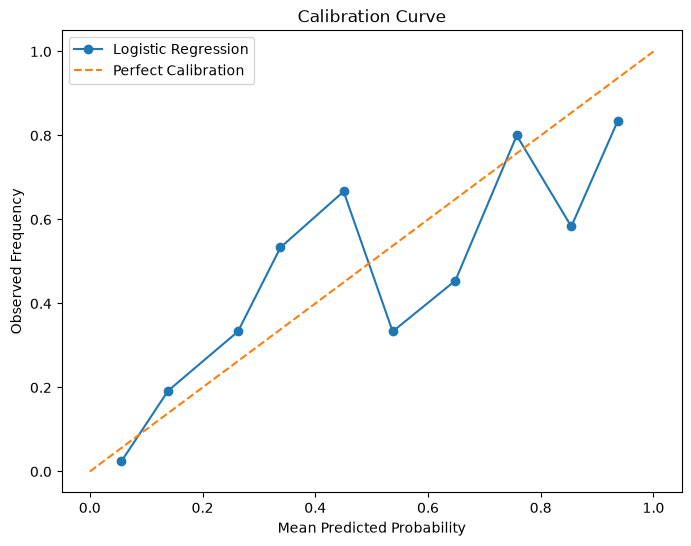

In [22]:
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()

plt.show()

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Scaled Logistic Regression model trained!")

Scaled Logistic Regression model trained!


In [24]:
explainer = shap.Explainer(
    logistic_model,
    X_train_scaled,
    feature_names=X_train.columns
)

shap_values = explainer(
    X_test_scaled
)

print("SHAP values calculated successfully!")

Background dataset has 614 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=614 when initializing the masker.


SHAP values calculated successfully!


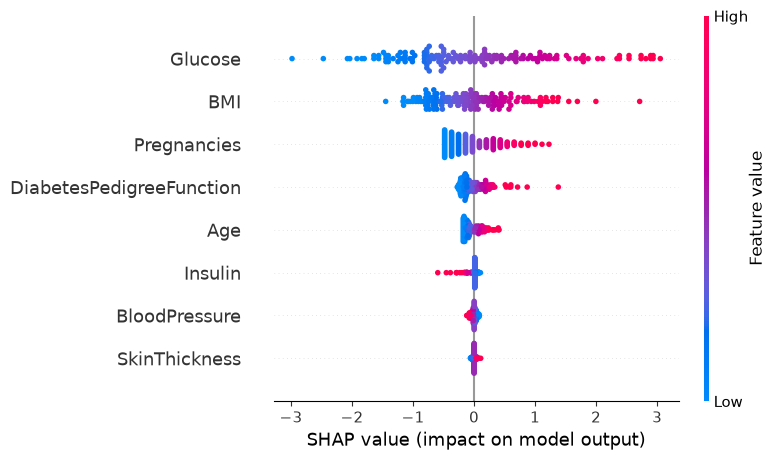

In [25]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test.columns
)

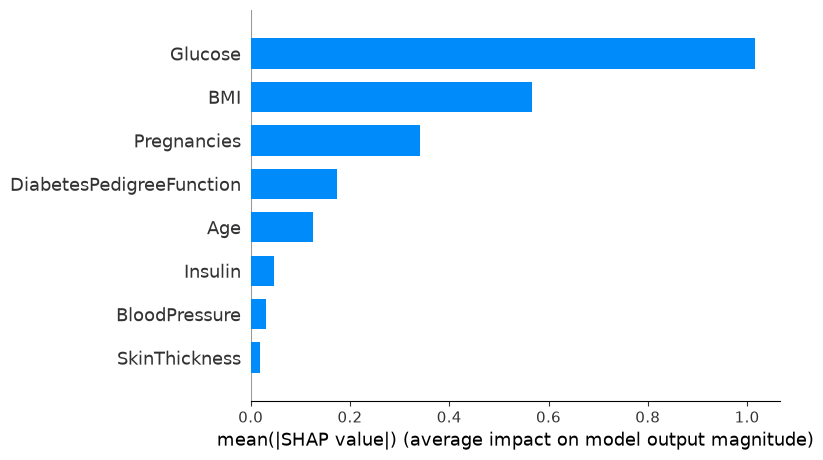

In [26]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test.columns,
    plot_type="bar"
)

In [28]:
sample_index = 0

print("Actual Outcome:",
      y_test.iloc[sample_index])

print("Predicted Outcome:",
      y_pred[sample_index])

print("Predicted Probability of Diabetes:",
      round(y_prob[sample_index], 4))

Actual Outcome: 0
Predicted Outcome: 1
Predicted Probability of Diabetes: 0.6097


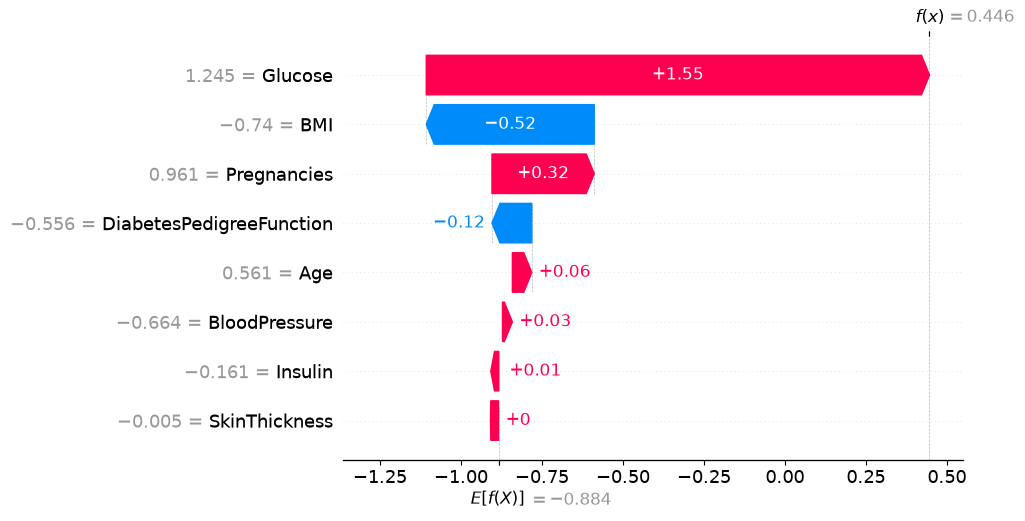

In [29]:
shap.plots.waterfall(
    shap_values[sample_index],
    max_display=10
)